In [24]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import pandas as pd
from utils.preprocess import *
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *
from eval.eval import *
import matplotlib.pyplot as plt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [25]:
############################################################

In [26]:
config = load_config(overrides=['dataset=mouse'])
OmegaConf.set_struct(config, False)

config.classifier.num_layers = 2
config.classifier.hidden_dim = 128
config.classifier.epsilon = 0.05

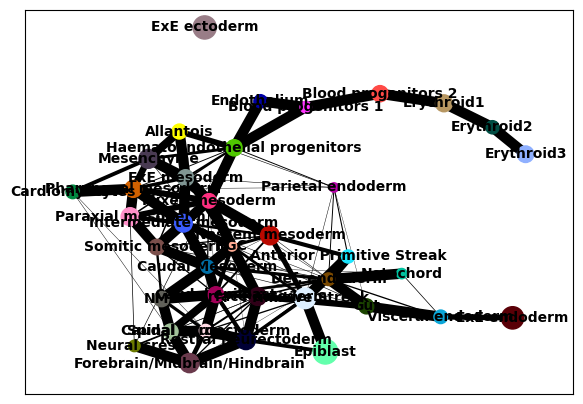

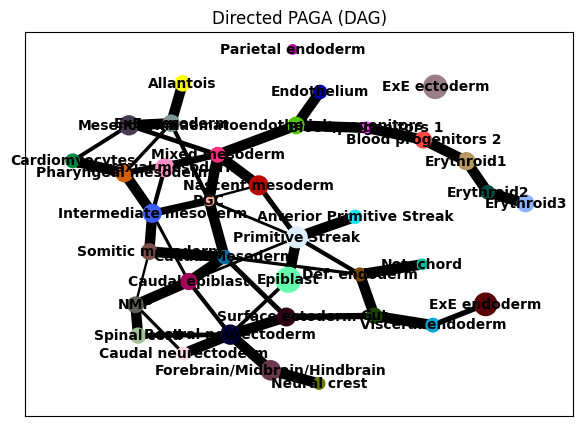

In [27]:
path = "data"
cache_file = os.path.join(path, "atlas", "mouse_preprocessed.h5ad")
adata = sc.read(cache_file)

adata.obs['cell_type'] = adata.obs['celltype'].astype(str)

stage_to_num = {
'E6.5': 6.5, 'E6.75': 6.75, 'E7.0': 7.0, 'E7.25': 7.25,
'E7.5': 7.5, 'E7.75': 7.75, 'E8.0': 8.0, 'E8.25': 8.25, 'E8.5': 8.5
}
adata.obs['timepoint'] = adata.obs['stage'].map(stage_to_num).astype(float)

# PCA
sc.tl.pca(adata, n_comps=config.pc_dim, mask_var=None)
adata.uns['std'] = np.ones((1, config.pc_dim))

sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.paga(adata, groups='cell_type')
sc.pl.paga(adata, threshold=0.03, show=False)

directed_conn, _ = enforce_dag_from_root(
adata, 
root_cell_type="Epiblast",
groups='cell_type',
threshold=0.2
)

original_conn = adata.uns['paga']['connectivities'].copy()
adata.uns['paga']['connectivities'] = adata.uns['paga']['connectivities_dag']

sc.pl.paga(adata, threshold=0.2, title='Directed PAGA (DAG)')
adata.uns['paga']['connectivities'] = original_conn

In [ ]:
### SETTINGS ###

adata = process_data(pc_dim=config.pc_dim, 
                     t0_index=config.t0_index,
                     t1_index=config.t1_index,
                     data=config.dataset, 
                     use_paga=config.use_paga,
                     paga_threshold=config.paga_threshold,
                     tissue=config.tissue)

print(adata.obs['cell_type'].nunique())

timepoints = sorted(adata.obs['timepoint'].unique().tolist())
tree = adata.uns['tree']

config.num_classes = adata.obs['cell_type'].nunique()

print(config.t0_index)
print(config.t1_index)

Loading cached preprocessed mouse data...
35
3
8


/home/azweig/projects/finfm/utils/lineage.py:255: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['stoi'] = stoi


In [6]:
#TODO: try removing samples
# adata[adata.obs['timepoint'] == timepoints[config.t0_index]].obs['sample'].unique()

In [7]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

adata = adata[(adata.obs['timepoint'] >= t0) & (adata.obs['timepoint'] <= t1)]
adata_train = adata[adata.obs['timepoint'].isin([t0, t1])]

print(t0, t1)

7.25 8.5


In [8]:
# # Explore cell types and stages
# print("Cell types:")
# for ct in sorted(adata.obs['cell_type'].unique()):
#     n = (adata.obs['cell_type'] == ct).sum()
#     print(f"  {ct}: {n}")

# print(f"\nStages:")
# for t in timepoints:
#     n = (adata.obs['timepoint'] == t).sum()
#     print(f"  {t}: {n}")

In [9]:
# # Visualize tree structure
# itos = adata.uns['itos']
# N = adata.uns['tree'].shape[0]
# print("Tree edges:")
# for i in range(N):
#     for j in range(N):
#         if adata.uns['tree'][i][j] == 1.0:
#             print(f"  {itos[i]} -> {itos[j]}")

In [10]:
# #CFM
# config.metric = "cfm"
# config.no_learning = True
# config.metric_max_epochs = 2

In [11]:
# #CFM + Finsler
# config.metric = "cfm"

# config.finsler.use = True
# config.finsler.lamb = 0.5
# config.balance_classes = False
# config.metric_max_epochs = 2

In [12]:
# #MFM-Euc
# config.metric = "mfm"
# config.mfm.use_euclidean_ot = True

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

In [13]:
# #MFM
# config.metric = "mfm"

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

In [14]:
#MFM + Finsler
config.metric = "mfm"

config.mfm.K = 150
config.mfm.kappa = 1.5
config.mfm.epsilon = 1e-1

config.finsler.use = True
config.finsler.lamb = 0.5

In [15]:
adata

View of AnnData object with n_obs × n_vars = 81066 × 2000
    obs: 'cell', 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'n_genes', 'cell_type', 'timepoint', 'cell_type_one_hot'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca', 'std', 'neighbors', 'paga', 'cell_type_sizes', 'stoi', 'itos', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [16]:
singleton_dataloader = build_singleton_dataloader(config, adata_train)
paired_dataloader = build_paired_dataloader(config, adata_train)

In [17]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=config.project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

{'pc_dim': 100, 'num_classes': 35, 'seed': 42, 'classifier_max_epochs': 1000, 'metric_max_epochs': 3000, 'embed_max_epochs': 3000, 'flow_max_epochs': 2, 'gradient_clip_val': 0, 'warmup_steps': 0, 'loader_batch_size': 6, 'flow_batch_size': 512, 'score_batch_size': 2048, 'ema_decay': '1-1e-3', 'use_paga': False, 'lr': 0.001, 'dropout': 0.0, 'hidden_dim': 256, 'latent_dim': 100, 'num_layers': 3, 'num_freq': 32, 'rescale': 0.5, 'skip': False, 'normalize': True, 'balance_classes': False, 'force_cpu': False, 'detect_anomaly': False, 'use_wandb': True, 'dummy_prior': 0.05, 'dummy_kl_weight': 0.05, 'classifier': {'hidden_dim': 128, 'num_layers': 2, 'spectral_norm': False, 'epsilon': 0.05}, 'metric': 'mfm', 'sigma': 0.0, 'ot_in_embed': True, 'fast_ot': False, 'no_learning': False, 'time_per_batch': 4, 'random_velocities': False, 'method': 'exact', 'reg': -1, 'reg_m': -1, 'mfm': {'K': 150, 'kappa': 1.5, 'alpha': 1.0, 'epsilon': 0.1, 'use_euclidean_ot': False}, 'finsler': {'use': True, 'temp': 1.

wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

epoch,▁▁▁▁▁▁▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
train_ce,█▄▃▂▃▄▂▂▂▃▂▂▂▂▂▃▁▂▁▂▂▁▂▂▂▁▃▁▂▁▁▂▂▂▂▂▂▂▂▁
train_kl,▁▆████▇▆█▆▅▄▃▃▃▄▂▃▃▃▃▃▃▂▂▂▃▂▂▂▂▃▂▂▂▂▂▂▂▂
train_loss_classifier,█▄▄▄▅▂▃▃▂▃▄▄▄▃▃▃▅▄▃▂▂▁▃▁▂▃▂▃▂▃▂▁▃▂▂▂▁▂▂▃
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇███
epoch,999
train_ce,1.01522
train_kl,2.4319
train_loss_classifier,1.13681
trainer/global_step,13999


Running phase metric:.......


...

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇██
train_loss_metric,███▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█
epoch,2999
train_loss_metric,70.98256
trainer/global_step,41999


Running phase embed:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 184 K  | train
1 | geo_net      | SinNet         | 226 K  | train
2 | metric_model | FinslerMFM     | 34.7 K | eval 
  | other params | n/a            | 50     | n/a  
--------------------------------------------------------
411 K     Trainable params
34.7 K    Non-trainable params
446 K     Total params
1.785     Total estimated

Restored best model from epoch 2861 with train_loss_geo_embed=3.228244


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇█
train_loss_embed,█▄▃▄▄▃▄▃▃▃▃▃▃▃▃▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁
train_loss_geo,█▅█▃▃▂▂▂▃▁▃▂▄▁▁▂▁▂▂▂▁▂▁▁▂▂▂▂▂▂▂▂▁▁▂▂▃▂▂▃
train_loss_geo_embed,█▆▅▂▂▂▂▁▁▂▂▂▂▁▁▂▂▁▁▂▁▁▁▁▁▁▂▂▁▁▁▁▁▁▁▁▂▂▁▁
trainer/global_step,▁▁▁▁▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇████
epoch,2999
train_loss_embed,0.28002
train_loss_geo,3.88219
train_loss_geo_embed,4.16221
trainer/global_step,2999


In [18]:
remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [19]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

w1_scores = []
for index in range(config.t0_index + 1, config.t1_index):
    print(index)
    t = timepoints[index]
    w1 = predict(embed_model, adata, t0, t, t1, num_traj=6000, library="pot")
    w1_scores.append(w1)
w1_scores = torch.tensor(w1_scores)
print(w1_scores)
print(torch.mean(w1_scores))

4


/home/azweig/projects/finfm/models/embed_models.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(j)
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/ot/lp/_network_simplex.py:574: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)


5
6
7
tensor([8.1963, 7.7403, 7.4409, 7.3381])
tensor(7.6789)


/tmp/ipykernel_1142263/3996609977.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())


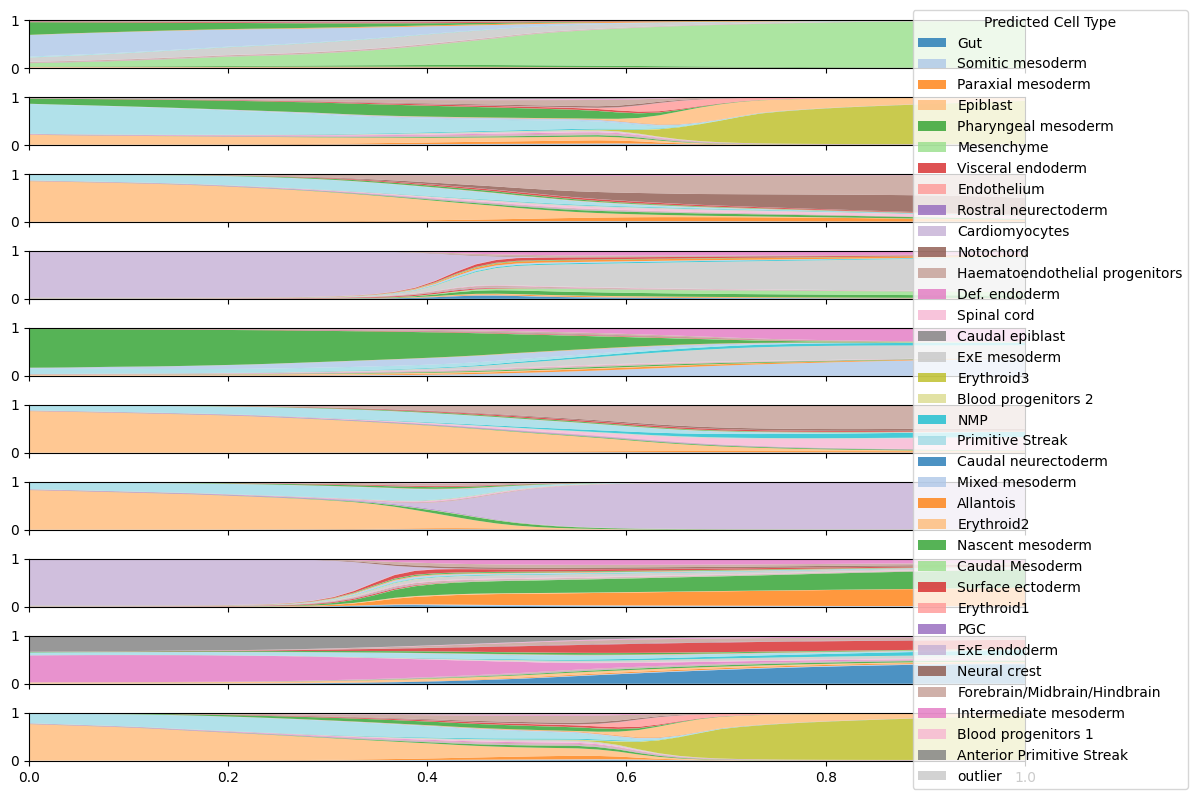

In [20]:
device = embed_model.device

batch = next(iter(paired_dataloader))
x0, x1, _, _ = embed_model._prepare_batch(batch)

paths = embed_model.sample_geodesic_path(batch, num_points=50)
paths_flat = paths.reshape(-1, paths.shape[-1])

time_axis = np.linspace(0, 1, 50)

with torch.no_grad():
    logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    
probs = probs.reshape(paths.shape[0], paths.shape[1], -1)

itos = adata.uns['itos']
cell_types = [itos[i] for i in range(len(itos))] + ["outlier"]

fig, axes = plt.subplots(10, figsize=(12, 8), sharex=True, sharey=True)

flat_axes = axes.flatten()

for i in range(len(flat_axes)):
    traj = probs[:,i]
    ax = flat_axes[i]
    ax.stackplot(time_axis, traj.T, labels=cell_types, alpha=0.8, colors=plt.cm.tab20.colors)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

handles, labels = flat_axes[0].get_legend_handles_labels()

fig.legend(
    handles, 
    labels, 
    loc='center right',
    bbox_to_anchor=(1, 0.5),
    title="Predicted Cell Type"
)

plt.tight_layout(rect=[0, 0, 0.88, 1]) 
plt.show()

In [21]:
start = paths[0,:30]
end = paths[-1,:30]
itos = adata.uns['itos']
start_classes = torch.argmax(classifier_model.classify(start), dim=1).detach().cpu().numpy()
start_classes = [itos[i] for i in start_classes]
end_classes = torch.argmax(classifier_model.classify(end), dim=1).detach().cpu().numpy()
end_classes = [itos[i] for i in end_classes]

for i in range(10):
    print(f"{start_classes[i]:<50} {end_classes[i]:>50}")

Mixed mesoderm                                                                             Mesenchyme
Primitive Streak                                                                           Erythroid3
Epiblast                                                                 Forebrain/Midbrain/Hindbrain
ExE endoderm                                                                             ExE mesoderm
Nascent mesoderm                                                                     Somitic mesoderm
Epiblast                                                                 Forebrain/Midbrain/Hindbrain
Epiblast                                                                               Cardiomyocytes
ExE endoderm                                                                        Paraxial mesoderm
Def. endoderm                                                                                     Gut
Epiblast                                                                          

In [22]:
paths.shape

torch.Size([50, 512, 100])

In [ ]:
#3->8
#PCA on everything

#CFM: 7.8333
#CFM + Finsler: 8.1958

#MFM-Euc: 
#MFM: 7.5061
#MFM + Finsler: 7.6789